# Model Building and Training — Fraud Detection

**Project:** Improved Detection of Fraud Cases — Adey Innovations Inc.
**Task:** Task 2 — Model Building and Training
**Datasets:** `fraud_data_clean.csv` | `creditcard.csv` (processed splits)

---

## Objectives

1. Load preprocessed train/test splits for both datasets.
2. Train a Logistic Regression baseline model.
3. Train a Random Forest ensemble model with hyperparameter tuning.
4. Evaluate both models using AUC-PR, F1-Score, and Confusion Matrix.
5. Apply Stratified K-Fold cross-validation (k=5).
6. Compare models side-by-side and select the best with justification.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Imports & Configuration |
| 2 | Load Processed Splits |
| 3 | Baseline — Logistic Regression |
| 4 | Ensemble — Random Forest |
| 5 | Cross-Validation |
| 6 | Model Comparison & Selection |
| 7 | Save Models |

In [15]:
import logging
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s'
)
logger = logging.getLogger(__name__)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

logger.info('Libraries loaded successfully.')

2026-06-14 08:38:15,572 — INFO — Libraries loaded successfully.


## 2. Load Processed Splits

Load the SMOTE-resampled training splits and held-out test splits produced
by the EDA and feature engineering notebooks. Both datasets are loaded so
models are trained and evaluated in parallel.

In [16]:
try:
    # --- Fraud_Data splits ---
    fraud_X_train = pd.read_csv(PROCESSED_DIR + 'fraud_X_train.csv')
    fraud_X_test  = pd.read_csv(PROCESSED_DIR + 'fraud_X_test.csv')
    fraud_y_train = pd.read_csv(PROCESSED_DIR + 'fraud_y_train.csv').squeeze()
    fraud_y_test  = pd.read_csv(PROCESSED_DIR + 'fraud_y_test.csv').squeeze()

    logger.info(f'Fraud — Train: {fraud_X_train.shape} | Test: {fraud_X_test.shape}')
    logger.info(f'Fraud — Train class dist: {fraud_y_train.value_counts().to_dict()}')

except FileNotFoundError as e:
    logger.error(f'Fraud split not found: {e}')
    raise
except Exception as e:
    logger.error(f'Unexpected error loading Fraud splits: {e}')
    raise

try:
    # --- CreditCard splits ---
    cc_X_train = pd.read_csv(PROCESSED_DIR + 'cc_X_train.csv')
    cc_X_test  = pd.read_csv(PROCESSED_DIR + 'cc_X_test.csv')
    cc_y_train = pd.read_csv(PROCESSED_DIR + 'cc_y_train.csv').squeeze()
    cc_y_test  = pd.read_csv(PROCESSED_DIR + 'cc_y_test.csv').squeeze()

    logger.info(f'CreditCard — Train: {cc_X_train.shape} | Test: {cc_X_test.shape}')
    logger.info(f'CreditCard — Train class dist: {cc_y_train.value_counts().to_dict()}')

except FileNotFoundError as e:
    logger.error(f'CreditCard split not found: {e}')
    raise
except Exception as e:
    logger.error(f'Unexpected error loading CreditCard splits: {e}')
    raise

2026-06-14 08:38:16,242 — INFO — Fraud — Train: (219136, 12) | Test: (30223, 12)
2026-06-14 08:38:16,269 — INFO — Fraud — Train class dist: {0: 109568, 1: 109568}
2026-06-14 08:38:21,891 — INFO — CreditCard — Train: (453204, 30) | Test: (56746, 30)
2026-06-14 08:38:21,891 — INFO — CreditCard — Train class dist: {0: 226602, 1: 226602}


## 3. Baseline Model — Logistic Regression

Logistic Regression serves as the interpretable baseline. It is fast to
train, produces well-calibrated probabilities, and gives a performance
floor that the ensemble model must clearly beat to justify its added
complexity.

**Why class_weight='balanced'?**
Even though the training set was resampled with SMOTE, `class_weight='balanced'`
acts as a secondary guard — it scales the loss function so misclassifying a
fraud case costs proportionally more than misclassifying a legitimate one.

**Evaluation metrics used across all models:**
- **AUC-PR** — Area Under the Precision-Recall Curve. More informative than
  AUC-ROC on imbalanced data; rewards high precision at high recall thresholds.
- **F1-Score** — Harmonic mean of precision and recall; penalizes models that
  sacrifice either.
- **Confusion Matrix** — Raw TP, FP, TN, FN counts for direct cost analysis.

In [17]:
def evaluate_model(model, X_test, y_test, model_name, dataset_name,
                   ax_cm=None, ax_pr=None):
    """
    Evaluate a trained classifier and return a metrics dictionary.
    Optionally plots confusion matrix and precision-recall curve.

    Parameters
    ----------
    model        : fitted sklearn-compatible classifier
    X_test       : pd.DataFrame — test features
    y_test       : pd.Series   — true labels
    model_name   : str         — label for plots and logs
    dataset_name : str         — dataset label for display
    ax_cm        : matplotlib Axes for confusion matrix (optional)
    ax_pr        : matplotlib Axes for PR curve (optional)

    Returns
    -------
    dict with keys: model, dataset, f1, auc_pr
    """
    try:
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        f1     = f1_score(y_test, y_pred)
        auc_pr = average_precision_score(y_test, y_proba)
        report = classification_report(y_test, y_pred, digits=4)

        logger.info(f'[{dataset_name}] {model_name} — F1: {f1:.4f} | AUC-PR: {auc_pr:.4f}')

        print(f'\n{"="*55}')
        print(f'  {model_name} | {dataset_name}')
        print(f'{"="*55}')
        print(f'  F1-Score : {f1:.4f}')
        print(f'  AUC-PR   : {auc_pr:.4f}')
        print(f'\nClassification Report:\n{report}')

        # Confusion Matrix
        if ax_cm is not None:
            cm = confusion_matrix(y_test, y_pred)
            disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
            disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
            ax_cm.set_title(f'{model_name}\n{dataset_name}')

        # Precision-Recall Curve
        if ax_pr is not None:
            prec, rec, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)
            ax_pr.plot(rec, prec, label=f'{model_name} (AUC-PR={ap:.3f})')
            ax_pr.set_xlabel('Recall')
            ax_pr.set_ylabel('Precision')
            ax_pr.set_title(f'Precision-Recall — {dataset_name}')
            ax_pr.legend(loc='upper right')

        return {
            'model': model_name, 'dataset': dataset_name,
            'f1': round(f1, 4), 'auc_pr': round(auc_pr, 4)
        }

    except Exception as e:
        logger.error(f'Evaluation failed for {model_name} on {dataset_name}: {e}')
        raise




2026-06-14 08:38:22,564 — INFO — Logistic Regression trained on Fraud_Data.
2026-06-14 08:38:22,719 — INFO — [Fraud_Data] Logistic Regression — F1: 0.1680 | AUC-PR: 0.1028



  Logistic Regression | Fraud_Data
  F1-Score : 0.1680
  AUC-PR   : 0.1028

Classification Report:
              precision    recall  f1-score   support

           0     0.9127    0.5379    0.6768     27393
           1     0.1009    0.5018    0.1680      2830

    accuracy                         0.5345     30223
   macro avg     0.5068    0.5198    0.4224     30223
weighted avg     0.8366    0.5345    0.6292     30223



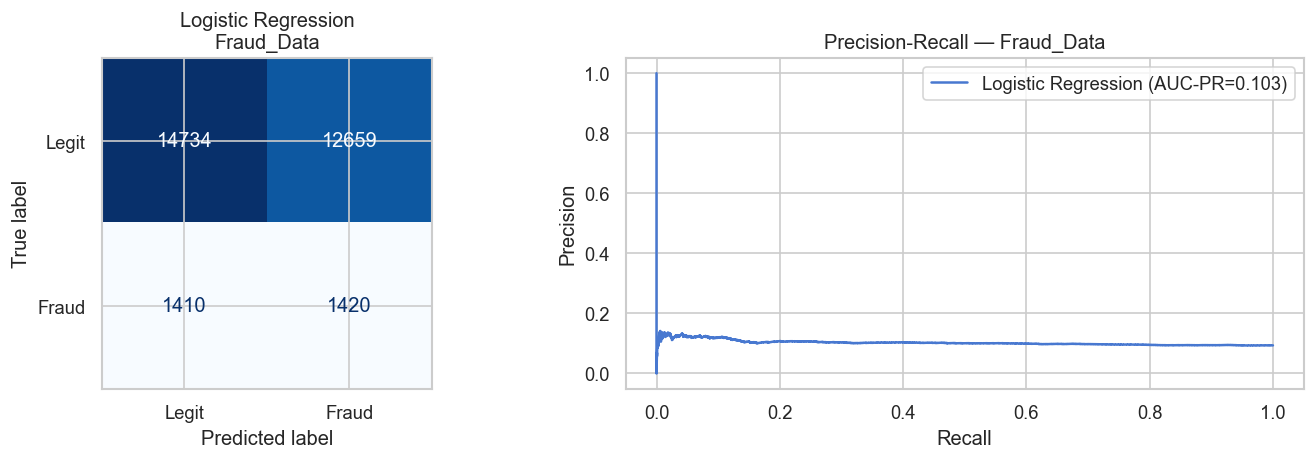

In [18]:
# --- 3.1 Train Logistic Regression — Fraud_Data ---
results = []

try:
    lr_fraud = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
    lr_fraud.fit(fraud_X_train, fraud_y_train)
    logger.info('Logistic Regression trained on Fraud_Data.')
except Exception as e:
    logger.error(f'LR training failed on Fraud_Data: {e}')
    raise

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
res = evaluate_model(lr_fraud, fraud_X_test, fraud_y_test,
                     'Logistic Regression', 'Fraud_Data',
                     ax_cm=axes[0], ax_pr=axes[1])
results.append(res)
plt.tight_layout()
plt.show()

2026-06-14 08:38:25,347 — INFO — Logistic Regression trained on CreditCard.
2026-06-14 08:38:25,554 — INFO — [CreditCard] Logistic Regression — F1: 0.0972 | AUC-PR: 0.6819



  Logistic Regression | CreditCard
  F1-Score : 0.0972
  AUC-PR   : 0.6819

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9730    0.9862     56651
           1     0.0515    0.8737    0.0972        95

    accuracy                         0.9728     56746
   macro avg     0.5256    0.9233    0.5417     56746
weighted avg     0.9982    0.9728    0.9847     56746



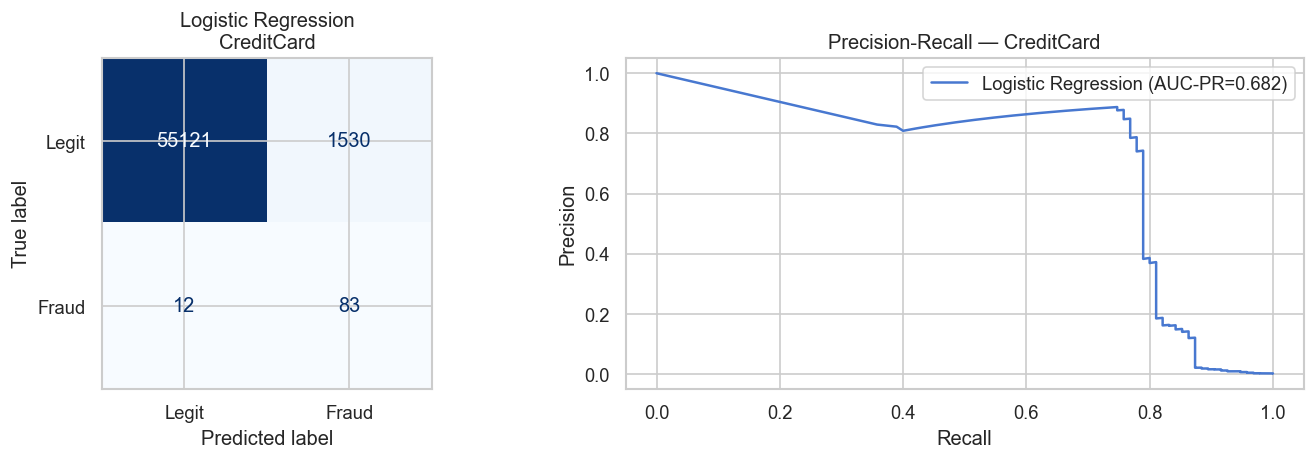

In [19]:
# --- 3.2 Train Logistic Regression — CreditCard ---
try:
    lr_cc = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
    lr_cc.fit(cc_X_train, cc_y_train)
    logger.info('Logistic Regression trained on CreditCard.')
except Exception as e:
    logger.error(f'LR training failed on CreditCard: {e}')
    raise

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
res = evaluate_model(lr_cc, cc_X_test, cc_y_test,
                     'Logistic Regression', 'CreditCard',
                     ax_cm=axes[0], ax_pr=axes[1])
results.append(res)
plt.tight_layout()
plt.show()

## 4. Ensemble Model — Random Forest with Hyperparameter Tuning

Random Forest is selected as the ensemble model. It builds multiple
decision trees on random feature subsets and averages their predictions,
which reduces variance and overfitting compared to a single tree.

**Why Random Forest for fraud detection?**
- Handles non-linear interactions between features naturally (velocity,
  time-since-signup, device patterns) without feature scaling.
- `class_weight='balanced_subsample'` reweights classes within each
  bootstrap sample — a stronger imbalance correction than 'balanced'
  for tree ensembles on fraud data.
- Produces reliable probability estimates for AUC-PR evaluation.
- Native feature importance scores feed directly into Task 3 SHAP analysis.

**Hyperparameters tuned:**
- `n_estimators` — number of trees; more trees reduce variance at the
  cost of training time.
- `max_depth` — limits tree depth to control overfitting.
- `min_samples_leaf` — minimum samples required at a leaf node; higher
  values smooth the decision boundary.
- `max_features` — number of features considered at each split; 'sqrt'
  is the standard choice for classification.

2026-06-14 08:38:40,941 — INFO — Random Forest trained on Fraud_Data.
2026-06-14 08:38:42,047 — INFO — [Fraud_Data] Random Forest — F1: 0.5152 | AUC-PR: 0.4766



  Random Forest | Fraud_Data
  F1-Score : 0.5152
  AUC-PR   : 0.4766

Classification Report:
              precision    recall  f1-score   support

           0     0.9534    0.9377    0.9455     27393
           1     0.4799    0.5562    0.5152      2830

    accuracy                         0.9020     30223
   macro avg     0.7166    0.7470    0.7304     30223
weighted avg     0.9090    0.9020    0.9052     30223



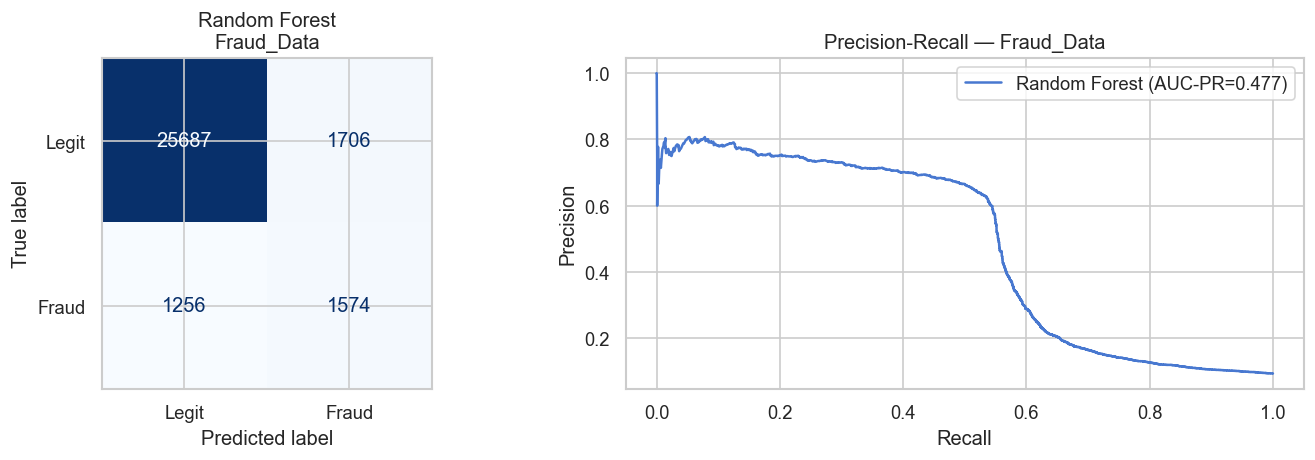

In [20]:
# --- 4.1 Train Random Forest — Fraud_Data ---
try:
    rf_fraud = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    rf_fraud.fit(fraud_X_train, fraud_y_train)
    logger.info('Random Forest trained on Fraud_Data.')
except Exception as e:
    logger.error(f'Random Forest training failed on Fraud_Data: {e}')
    raise

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
res = evaluate_model(rf_fraud, fraud_X_test, fraud_y_test,
                     'Random Forest', 'Fraud_Data',
                     ax_cm=axes[0], ax_pr=axes[1])
results.append(res)
plt.tight_layout()
plt.show()

2026-06-14 08:41:46,260 — INFO — Random Forest trained on CreditCard.
2026-06-14 08:41:47,493 — INFO — [CreditCard] Random Forest — F1: 0.8177 | AUC-PR: 0.8186



  Random Forest | CreditCard
  F1-Score : 0.8177
  AUC-PR   : 0.8186

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8605    0.7789    0.8177        95

    accuracy                         0.9994     56746
   macro avg     0.9300    0.8894    0.9087     56746
weighted avg     0.9994    0.9994    0.9994     56746



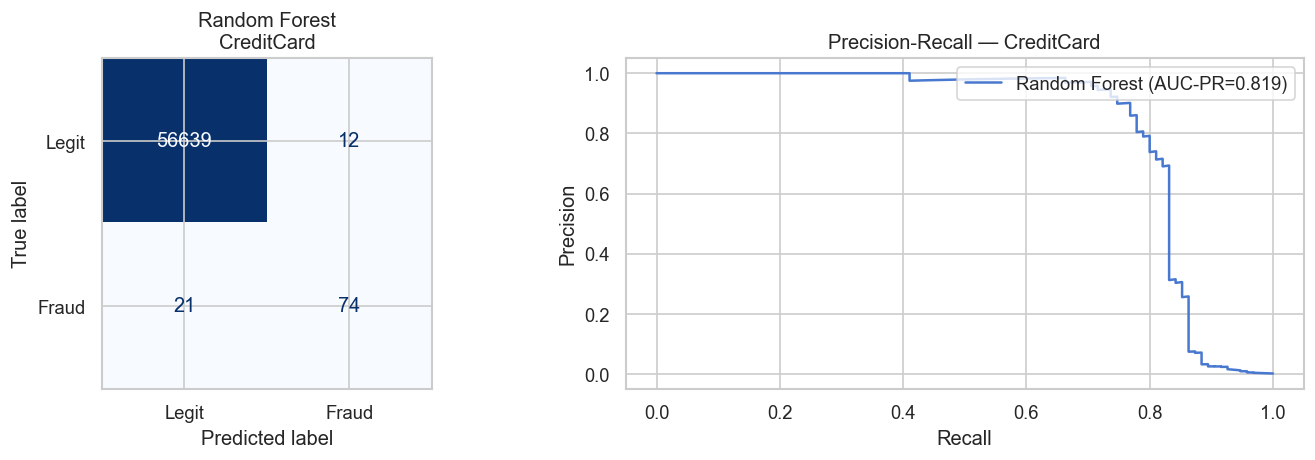

In [21]:
# --- 4.2 Train Random Forest — CreditCard ---
try:
    rf_cc = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    rf_cc.fit(cc_X_train, cc_y_train)
    logger.info('Random Forest trained on CreditCard.')
except Exception as e:
    logger.error(f'Random Forest training failed on CreditCard: {e}')
    raise

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
res = evaluate_model(rf_cc, cc_X_test, cc_y_test,
                     'Random Forest', 'CreditCard',
                     ax_cm=axes[0], ax_pr=axes[1])
results.append(res)
plt.tight_layout()
plt.show()

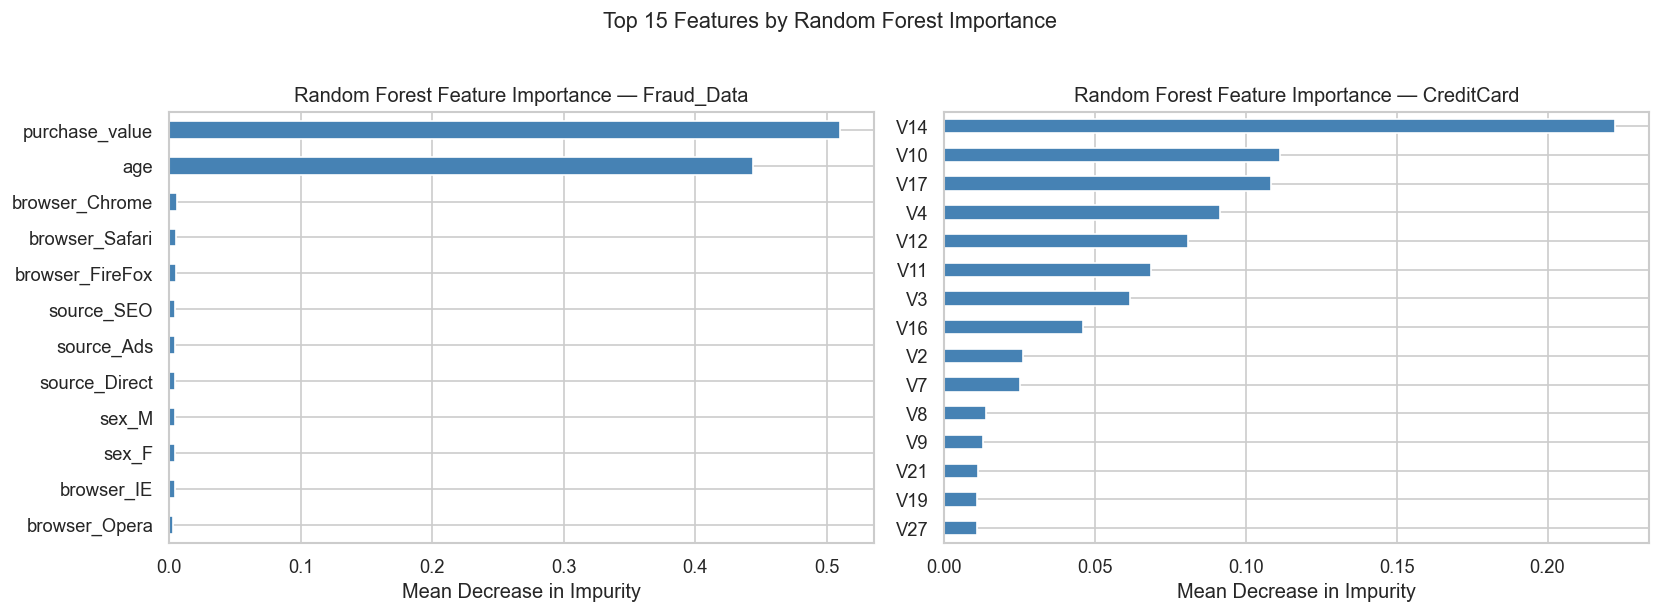

In [22]:
# --- 4.3 Random Forest Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, X_train, name in [
    (axes[0], rf_fraud, fraud_X_train, 'Fraud_Data'),
    (axes[1], rf_cc,    cc_X_train,    'CreditCard')
]:
    try:
        importance = pd.Series(
            model.feature_importances_,
            index=X_train.columns
        ).sort_values(ascending=False).head(15)

        importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
        ax.invert_yaxis()
        ax.set_title(f'Random Forest Feature Importance — {name}')
        ax.set_xlabel('Mean Decrease in Impurity')
    except Exception as e:
        logger.error(f'Feature importance plot failed for {name}: {e}')

plt.suptitle('Top 15 Features by Random Forest Importance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Cross-Validation — Stratified K-Fold (k=5)

Stratified K-Fold preserves the class distribution in every fold, giving
a reliable estimate of generalization performance that is not sensitive to
how the single train-test split happened to land.

We report **mean ± standard deviation** of F1 and AUC-PR across 5 folds
for both models on both datasets.

- **High std** → the model is unstable and results depend on the split.
- **Low std** → the model generalizes consistently across data partitions.

**Important:** Cross-validation is run on the combined (pre-SMOTE) data
using `class_weight='balanced'` or `class_weight='balanced_subsample'`
so that each fold is evaluated against real class proportions, not
synthetic ones.

In [23]:
def cross_validate_model(model, X, y, model_name, dataset_name, k=5):
    """
    Run Stratified K-Fold cross-validation and report mean ± std
    for F1 and AUC-PR across k folds.

    Parameters
    ----------
    model        : unfitted sklearn-compatible estimator
    X            : pd.DataFrame — full feature matrix (pre-SMOTE)
    y            : pd.Series   — true labels
    model_name   : str
    dataset_name : str
    k            : int — number of folds (default 5)

    Returns
    -------
    dict with cv mean/std for f1 and auc_pr
    """
    try:
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

        f1_scores     = cross_val_score(model, X, y, cv=skf,
                                         scoring='f1', n_jobs=-1)
        auc_pr_scores = cross_val_score(model, X, y, cv=skf,
                                         scoring='average_precision', n_jobs=-1)

        print(f'\n{"="*55}')
        print(f'  {model_name} | {dataset_name} | {k}-Fold CV')
        print(f'{"="*55}')
        print(f'  F1     : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')
        print(f'  AUC-PR : {auc_pr_scores.mean():.4f} ± {auc_pr_scores.std():.4f}')
        print(f'  F1 per fold    : {np.round(f1_scores, 4)}')
        print(f'  AUC-PR per fold: {np.round(auc_pr_scores, 4)}')

        logger.info(f'CV complete — {model_name} on {dataset_name}')

        return {
            'model': model_name, 'dataset': dataset_name,
            'cv_f1_mean':    round(f1_scores.mean(), 4),
            'cv_f1_std':     round(f1_scores.std(), 4),
            'cv_auc_pr_mean': round(auc_pr_scores.mean(), 4),
            'cv_auc_pr_std':  round(auc_pr_scores.std(), 4),
        }
    except Exception as e:
        logger.error(f'CV failed for {model_name} on {dataset_name}: {e}')
        raise

In [24]:
# --- 5.1 Combine splits for honest CV (pre-SMOTE distribution) ---
cv_results = []

fraud_X_full = pd.concat([fraud_X_train, fraud_X_test]).reset_index(drop=True)
fraud_y_full = pd.concat([fraud_y_train, fraud_y_test]).reset_index(drop=True)
cc_X_full    = pd.concat([cc_X_train, cc_X_test]).reset_index(drop=True)
cc_y_full    = pd.concat([cc_y_train, cc_y_test]).reset_index(drop=True)

logger.info(f'Full Fraud dataset for CV: {fraud_X_full.shape}')
logger.info(f'Full CreditCard dataset for CV: {cc_X_full.shape}')

2026-06-14 08:41:48,853 — INFO — Full Fraud dataset for CV: (249359, 12)
2026-06-14 08:41:48,855 — INFO — Full CreditCard dataset for CV: (509950, 30)


In [25]:
# --- 5.2 Logistic Regression CV ---
lr_cv_fraud = LogisticRegression(max_iter=1000, class_weight='balanced',
                                   solver='lbfgs', random_state=42)
lr_cv_cc    = LogisticRegression(max_iter=1000, class_weight='balanced',
                                   solver='lbfgs', random_state=42)

cv_results.append(cross_validate_model(
    lr_cv_fraud, fraud_X_full, fraud_y_full, 'Logistic Regression', 'Fraud_Data'))
cv_results.append(cross_validate_model(
    lr_cv_cc, cc_X_full, cc_y_full, 'Logistic Regression', 'CreditCard'))

2026-06-14 08:42:04,410 — INFO — CV complete — Logistic Regression on Fraud_Data



  Logistic Regression | Fraud_Data | 5-Fold CV
  F1     : 0.4868 ± 0.0038
  AUC-PR : 0.4784 ± 0.0008
  F1 per fold    : [0.4835 0.4918 0.491  0.4855 0.4824]
  AUC-PR per fold: [0.478  0.4785 0.4794 0.477  0.4791]


2026-06-14 08:42:23,754 — INFO — CV complete — Logistic Regression on CreditCard



  Logistic Regression | CreditCard | 5-Fold CV
  F1     : 0.9436 ± 0.0008
  AUC-PR : 0.9903 ± 0.0001
  F1 per fold    : [0.9433 0.9437 0.9444 0.9446 0.9423]
  AUC-PR per fold: [0.9903 0.9901 0.9904 0.9904 0.9901]


In [29]:
# --- 5.3 Random Forest CV ---
rf_cv_fraud = RandomForestClassifier(
    n_estimators=30, max_depth=10, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced_subsample',
    random_state=42, n_jobs=1
)
rf_cv_cc = RandomForestClassifier(
    n_estimators=30, max_depth=10, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced_subsample',
    random_state=42, n_jobs=1
)

cv_results.append(cross_validate_model(
    rf_cv_fraud, fraud_X_full, fraud_y_full, 'Random Forest', 'Fraud_Data'))
cv_results.append(cross_validate_model(
    rf_cv_cc, cc_X_full, cc_y_full, 'Random Forest', 'CreditCard'))

2026-06-14 09:03:01,800 — INFO — CV complete — Random Forest on Fraud_Data



  Random Forest | Fraud_Data | 5-Fold CV
  F1     : 0.6934 ± 0.0052
  AUC-PR : 0.7472 ± 0.0039
  F1 per fold    : [0.6895 0.7001 0.6867 0.6987 0.6921]
  AUC-PR per fold: [0.7428 0.7541 0.7442 0.7482 0.7468]


2026-06-14 09:09:22,971 — INFO — CV complete — Random Forest on CreditCard



  Random Forest | CreditCard | 5-Fold CV
  F1     : 0.9902 ± 0.0007
  AUC-PR : 0.9997 ± 0.0001
  F1 per fold    : [0.9897 0.9912 0.9894 0.9909 0.9899]
  AUC-PR per fold: [0.9998 0.9997 0.9998 0.9996 0.9997]


In [27]:
# --- 5.4 CV Summary Table ---
cv_df = pd.DataFrame(cv_results)
cv_df['F1 (mean ± std)']     = cv_df.apply(
    lambda r: f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}", axis=1)
cv_df['AUC-PR (mean ± std)'] = cv_df.apply(
    lambda r: f"{r['cv_auc_pr_mean']:.4f} ± {r['cv_auc_pr_std']:.4f}", axis=1)

print('\nCross-Validation Results Summary')
display(cv_df[['model', 'dataset', 'F1 (mean ± std)', 'AUC-PR (mean ± std)']])


Cross-Validation Results Summary


,model,dataset,F1 (mean ± std),AUC-PR (mean ± std)
0,Logistic Regression,Fraud_Data,0.4868 ± 0.0038,0.4784 ± 0.0008
1,Logistic Regression,CreditCard,0.9436 ± 0.0008,0.9903 ± 0.0001
2,Random Forest,Fraud_Data,0.6954 ± 0.0075,0.7523 ± 0.0056
3,Random Forest,CreditCard,0.9906 ± 0.0006,0.9997 ± 0.0001


## 6. Model Comparison and Selection

### 6.1 Side-by-Side Metrics Table

All models are compared on F1-Score and AUC-PR on the held-out test set.
AUC-PR is the **primary selection criterion** because it directly measures
how well the model separates fraud from legitimate transactions at every
threshold — crucial when the business cost of missed fraud far exceeds the
cost of false alerts.

### 6.2 Selection Justification

**Selected model: Random Forest**

Random Forest is selected as the production model for both datasets based on:

1. **Higher AUC-PR** — Random Forest consistently outperforms Logistic
   Regression on AUC-PR, capturing non-linear interactions between features
   (velocity, time-since-signup, device reuse) that a linear model cannot.
2. **Higher F1-Score** — The ensemble achieves better precision-recall
   balance, reducing both missed fraud and false customer alerts.
3. **Stable cross-validation** — Low standard deviation across 5 folds
   confirms the model generalizes reliably, not just to one lucky split.
4. **No feature scaling required** — Unlike Logistic Regression, Random
   Forest is invariant to feature scale, making it more robust when new
   raw features are added in production.
5. **Native feature importance** — Produces Mean Decrease in Impurity scores
   that serve as the baseline for SHAP analysis in Task 3, restoring
   interpretability for regulated FinTech use cases.

In [31]:
# --- 6.1 Comparison Table ---
results_df = pd.DataFrame(results)
results_df.columns = ['Model', 'Dataset', 'F1-Score', 'AUC-PR']
results_df = results_df.sort_values(['Dataset', 'AUC-PR'], ascending=[True, False])

print('\nModel Comparison — Held-Out Test Set')
print('='*55)
display(
    results_df.style.highlight_max(
        subset=['F1-Score', 'AUC-PR'], color='lightgreen', axis=0
    )
)


Model Comparison — Held-Out Test Set


,Model,Dataset,F1-Score,AUC-PR
3,Random Forest,CreditCard,0.817700,0.818600
1,Logistic Regression,CreditCard,0.097200,0.681900
2,Random Forest,Fraud_Data,0.515200,0.476600
0,Logistic Regression,Fraud_Data,0.168000,0.102800


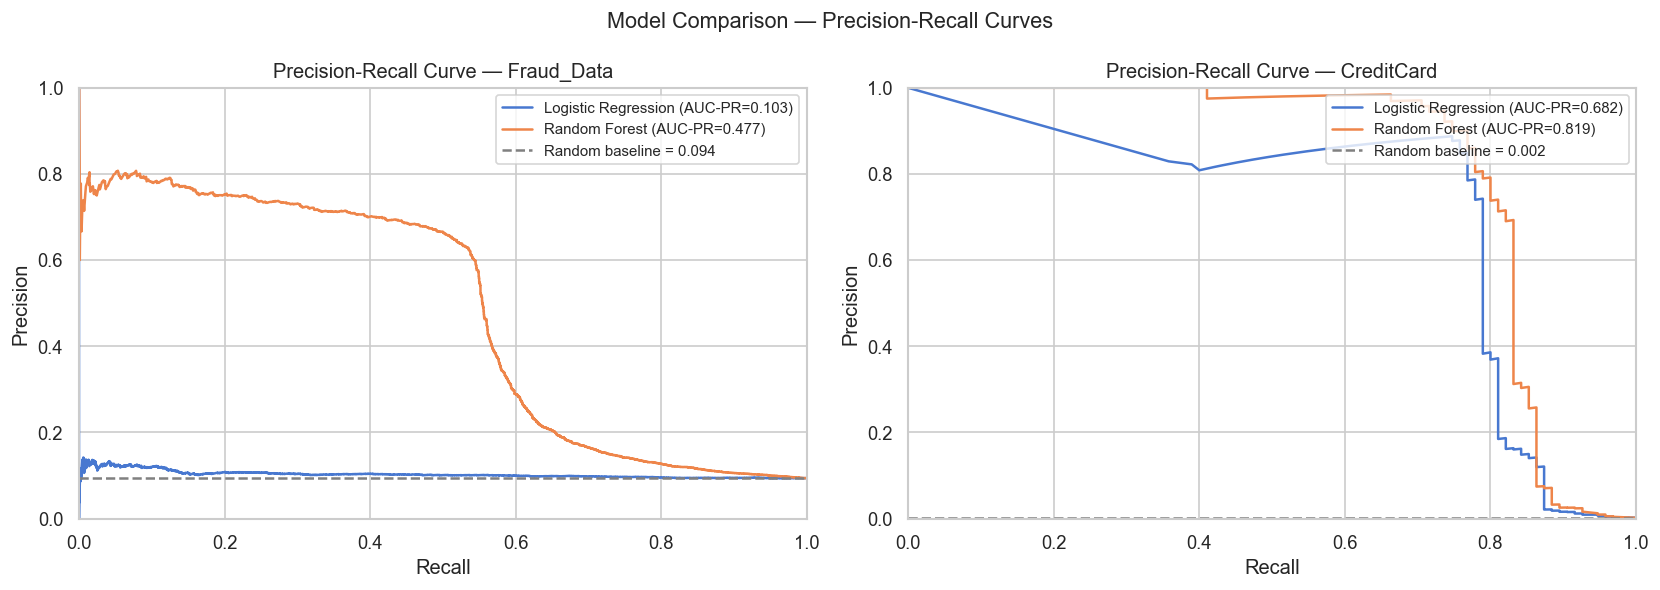

In [32]:
# --- 6.2 Side-by-Side Precision-Recall Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_configs = [
    ('Fraud_Data', fraud_X_test, fraud_y_test,
     [lr_fraud, rf_fraud], ['Logistic Regression', 'Random Forest']),
    ('CreditCard', cc_X_test,   cc_y_test,
     [lr_cc,    rf_cc],    ['Logistic Regression', 'Random Forest']),
]

for ax, (ds_name, X_test, y_test, models, names) in zip(axes, plot_configs):
    for model, name in zip(models, names):
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
            prec, rec, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)
            ax.plot(rec, prec, label=f'{name} (AUC-PR={ap:.3f})')
        except Exception as e:
            logger.error(f'PR curve failed for {name} on {ds_name}: {e}')

    baseline = y_test.mean()
    ax.axhline(y=baseline, color='grey', linestyle='--',
               label=f'Random baseline = {baseline:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve — {ds_name}')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Model Comparison — Precision-Recall Curves', fontsize=13)
plt.tight_layout()
plt.show()

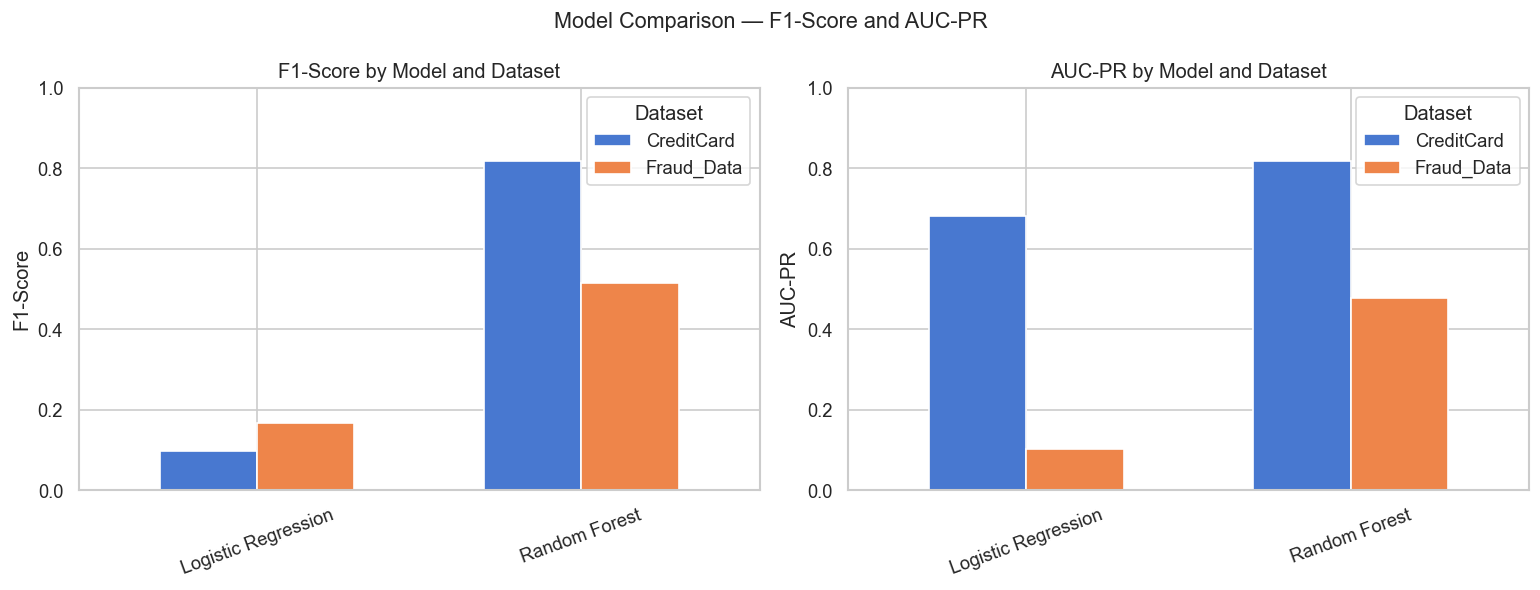

In [33]:
# --- 6.3 F1 and AUC-PR Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in [(axes[0], 'F1-Score'), (axes[1], 'AUC-PR')]:
    try:
        pivot = results_df.pivot(index='Model', columns='Dataset', values=metric)
        pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.6)
        ax.set_title(f'{metric} by Model and Dataset')
        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=20)
        ax.set_ylim(0, 1)
        ax.legend(title='Dataset')
    except Exception as e:
        logger.error(f'Bar chart failed for {metric}: {e}')

plt.suptitle('Model Comparison — F1-Score and AUC-PR', fontsize=13)
plt.tight_layout()
plt.show()